In [4]:
import tensorflow as tf
def count_tfrecord_examples(tfrecord_path):
    count = sum(1 for _ in tf.data.TFRecordDataset(tfrecord_path))
    return count

train_size = count_tfrecord_examples("/kaggle/input/ddsmtrainvaltfrecord/tfrecords/train.tfrecord")
val_size = count_tfrecord_examples("/kaggle/input/ddsmtrainvaltfrecord/tfrecords/val.tfrecord")

print("Train size:", train_size)
print("Validation size:", val_size)

Train size: 17359
Validation size: 3670


In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/ddsmtrainvaltfrecord/tfrecords/val.tfrecord
/kaggle/input/ddsmtrainvaltfrecord/tfrecords/train.tfrecord


In [6]:
print("TPU devices:", tf.config.experimental.list_logical_devices('TPU'))

TPU devices: [LogicalDevice(name='/device:TPU:0', device_type='TPU'), LogicalDevice(name='/device:TPU:1', device_type='TPU'), LogicalDevice(name='/device:TPU:2', device_type='TPU'), LogicalDevice(name='/device:TPU:3', device_type='TPU'), LogicalDevice(name='/device:TPU:4', device_type='TPU'), LogicalDevice(name='/device:TPU:5', device_type='TPU'), LogicalDevice(name='/device:TPU:6', device_type='TPU'), LogicalDevice(name='/device:TPU:7', device_type='TPU')]


In [7]:
# Connect to TPU
tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local') # Detect TPU
tf.config.experimental_connect_to_cluster(tpu)  # Ensure the connection to TPU
tf.tpu.experimental.initialize_tpu_system(tpu)

print("Running on TPU:", tpu.cluster_spec().as_dict())

# Create TPU Strategy
strategy = tf.distribute.TPUStrategy(tpu)
print("TPU Strategy initialized successfully!")

INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local
INFO:tensorflow:Finished initializing TPU system.
Running on TPU: {}
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:0, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:1, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:2, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:3, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:

In [9]:
import tensorflow as tf

def parse_tfrecord(example):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'mask': tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example, feature_description)

    image = tf.image.decode_png(parsed['image'], channels=1)
    mask = tf.image.decode_png(parsed['mask'], channels=1)

    image = tf.cast(image, tf.float32) / 255.0

    # Normalize and threshold mask to ensure binary values (0 or 1)
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0) 

    return image, mask

In [8]:
def load_datase3t(tfrecord_path, batch_size=32, shuffle=True):
    raw_dataset = tf.data.TFRecordDataset(tfrecord_path)
    dataset = raw_dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(1000)

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [10]:
def load_dataset(tfrecord_path, batch_size=160, shuffle=True, repeat=False):
    """
    Loads a TFRecord dataset, parses, shuffles, batches, and prefetches.

    Args:
        tfrecord_path (str): Path to the TFRecord file.
        batch_size (int): Batch size for training.
        shuffle (bool): Whether to shuffle the dataset.
        repeat (bool): Whether to repeat the dataset (for infinite streaming training).

    Returns:
        tf.data.Dataset: Prepared TensorFlow dataset.
    """
    raw_dataset = tf.data.TFRecordDataset(tfrecord_path)
    dataset = raw_dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(1000)

    if repeat:
        dataset = dataset.repeat()

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset


In [11]:
train_tfrecord = "/kaggle/input/ddsmtrainvaltfrecord/tfrecords/train.tfrecord"
val_tfrecord = "/kaggle/input/ddsmtrainvaltfrecord/tfrecords/val.tfrecord"

batch_size = 128

train_dataset = load_dataset(train_tfrecord, batch_size=batch_size, shuffle=True, repeat=True)
val_dataset = load_dataset(val_tfrecord, batch_size=batch_size, shuffle=False, repeat=False)

steps_per_epoch = train_size // batch_size
validation_steps = val_size // batch_size

In [12]:
for images, masks in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Mask batch shape:", masks.shape)

Image batch shape: (128, 256, 256, 1)
Mask batch shape: (128, 256, 256, 1)


In [12]:
for image, mask in train_dataset.take(1):  # get a single batch
    print("Image range:", tf.reduce_min(image).numpy(), "to", tf.reduce_max(image).numpy())
    print("Mask range:", tf.reduce_min(mask).numpy(), "to", tf.reduce_max(mask).numpy())

Image range: 0.0 to 1.0
Mask range: 0.0 to 1.0


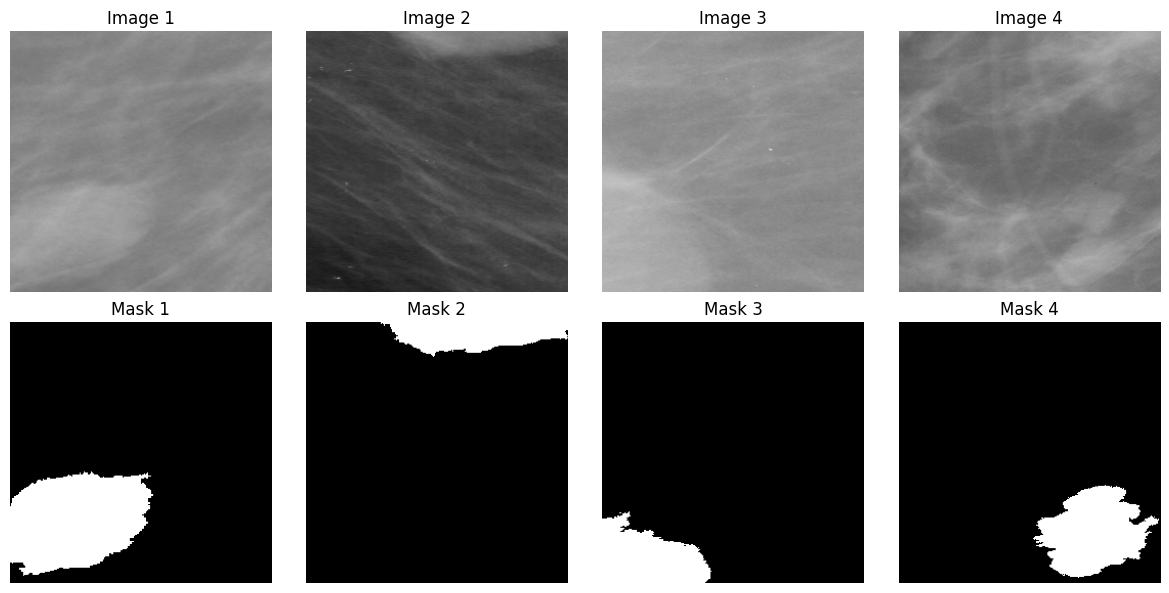

In [13]:
import matplotlib.pyplot as plt

images, masks = next(iter(train_dataset))

plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title(f"Image {i+1}")
    plt.axis('off')

    plt.subplot(2, 4, i+5)
    plt.imshow(masks[i].numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title(f"Mask {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

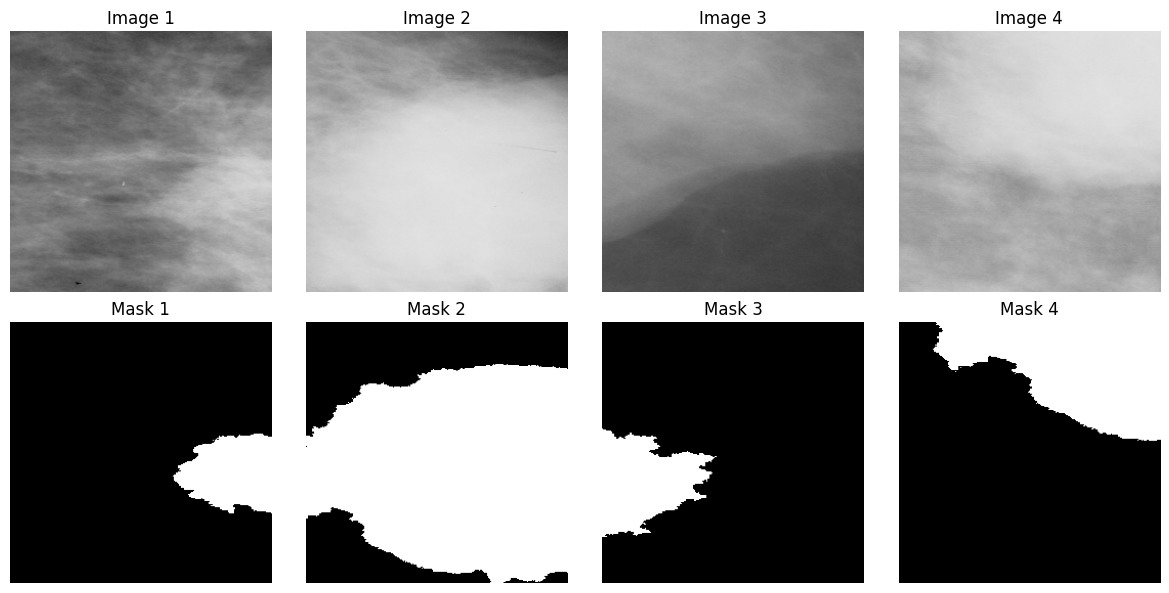

In [14]:
import matplotlib.pyplot as plt

images, masks = next(iter(train_dataset))

plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title(f"Image {i+1}")
    plt.axis('off')

    plt.subplot(2, 4, i+5)
    plt.imshow(masks[i].numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title(f"Mask {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
import tensorflow as tf

def dice_coe1f(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.cast(tf.keras.backend.flatten(y_true), tf.float32)
    y_pred_f = tf.cast(tf.keras.backend.flatten(y_pred), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    return (2. * intersection + smooth) / (union + smooth)

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    sum_values = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)

    return tf.where(
        tf.equal(sum_values, 0),
        1.0,  # Perfect match if both are empty
        (2. * intersection + smooth) / (sum_values + smooth)
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

# BCE + Dice loss
#def bce_dice_loss(y_true, y_pred):
 #   bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
  #  dice = dice_loss(y_true, y_pred)
   # return bce + dice

def bce_dice_loss(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

In [26]:

# --- Dice Coefficient and Loss ---
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

# --- Focal Loss ---
def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    pt = tf.exp(-bce)
    return alpha * tf.pow(1. - pt, gamma) * bce

# --- Combined Loss ---
def combo_loss(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    return dice_loss(y_true, y_pred) + focal_loss(y_true, y_pred)

In [19]:
import tensorflow as tf

def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fn = tf.reduce_sum(y_true_f * (1 - y_pred_f))
    fp = tf.reduce_sum((1 - y_true_f) * y_pred_f)

    tversky_index = (tp + smooth) / (tp + alpha * fn + beta * fp + smooth)
    return 1 - tversky_index

def bce_tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    tversky = tversky_loss(y_true, y_pred, alpha, beta)
    return bce + tversky

def tversky_metric(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fn = tf.reduce_sum(y_true_f * (1 - y_pred_f))
    fp = tf.reduce_sum((1 - y_true_f) * y_pred_f)

    return (tp + smooth) / (tp + alpha * fn + beta * fp + smooth)


In [16]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, concatenate

def conv_block(input, num_filters):
    conv = Conv2D(num_filters, (3, 3), activation="relu", padding="same", kernel_initializer='he_normal')(input)
    conv = Conv2D(num_filters, (3, 3), activation="relu", padding="same", kernel_initializer='he_normal')(conv)
    return conv

def encoder_block(input, num_filters):
    conv = conv_block(input, num_filters)
    pool = MaxPooling2D((2, 2))(conv)
    return conv, pool

def decoder_block(input, skip_features, num_filters):
    uconv = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input)
    con = concatenate([uconv, skip_features])
    conv = conv_block(con, num_filters)
    return conv

def unet_model(input_shape):
    input_layer = Input(input_shape)
    
    s1, p1 = encoder_block(input_layer, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b1 = conv_block(p4, 1024)

    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    
    output_layer = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = Model(input_layer, output_layer, name="U-Net")
    return model

In [23]:
import tensorflow as tf

def tversky_loss_safe(y_true, y_pred, alpha=0.5, beta=0.5, smooth=1e-6):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)  # Avoid log(0) or divide by 0

    # Flatten tensors
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    # Skip if ground truth is empty (all 0s)
    sum_gt = tf.reduce_sum(y_true_f)
    def zero_loss(): return tf.constant(0.0)
    
    def compute_tversky():
        TP = tf.reduce_sum(y_true_f * y_pred_f)
        FP = tf.reduce_sum((1 - y_true_f) * y_pred_f)
        FN = tf.reduce_sum(y_true_f * (1 - y_pred_f))
        return 1 - (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)

    return tf.cond(sum_gt == 0, zero_loss, compute_tversky)

def safe_bce_tversky_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    tversky = tversky_loss_safe(y_true, y_pred)
    return bce + tversky


In [17]:
from tensorflow.keras import layers
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

with strategy.scope():   
    model = unet_model(input_shape=(256, 256, 1))
    model.summary()
    model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss= bce_dice_loss,
              metrics=[dice_coef])

  #  model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
   #           loss=combo_loss,   # or whichever worked best
    #          metrics=[dice_coef])

    #model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    checkpointer = ModelCheckpoint('/kaggle/working/unet-tpu.h5', save_best_only=True, verbose=1)
    early_stop = EarlyStopping(patience=15, restore_best_weights=True)

   # history = model.fit(
   # train_dataset,
   # validation_data=val_dataset,
   # epochs=50,
   # steps_per_epoch=steps_per_epoch,
   # validation_steps=validation_steps,
   # callbacks=[checkpointer, early_stop]

    history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    steps_per_epoch=40,              # Limit training steps per epoch
    #validation_steps=15,             # Optional: limit validation steps too
    callbacks=[checkpointer, early_stop]
)

model.save_weights("/kaggle/working/ddsmtrainvaltfrecord-tpu-unetf.weights.h5")

I0000 00:00:1744053354.398295      10 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 31,030,593 (118.37 MB)

 Trainable params: 31,030,593 (118.37 MB)

...

40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 518ms/step - dice_coef: 0.4764 - loss: 0.8512 - val_dice_coef: 0.5143 - val_loss: 0.6997
Epoch 33/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.4792 - loss: 0.7675
Epoch 33: val_loss improved from 0.69969 to 0.65289, saving model to /kaggle/working/unet-tpu.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 528ms/step - dice_coef: 0.4792 - loss: 0.7675 - val_dice_coef: 0.5655 - val_loss: 0.6529
Epoch 34/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.5096 - loss: 0.8483
Epoch 34: val_loss did not improve from 0.65289
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 481ms/step - dice_coef: 0.5096 - loss: 0.8483 - val_dice_coef: 0.5218 - val_loss: 0.6940
Epoch 35/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.4720 - loss: 0.8179
Epoch 35: val_loss did not improve from 0.65289
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 489ms/step - dice_coef: 0.4720 - loss: 0.8179 - val_dice_coef: 0.5511 - val_loss: 0.6899
Epoch 36/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.4877 - loss: 0.8224
Epoch 36: val_loss did not improve from 0.65289
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 486ms/step - dice_coef: 0.4877 - loss: 0.8224 - val_dice_coef: 0.5341 - val_loss: 0.7433
Epoch 37/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.5512 - loss: 0.7549
Epoch 37: val_loss did n

40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 530ms/step - dice_coef: 0.5411 - loss: 0.7280 - val_dice_coef: 0.5620 - val_loss: 0.6493
Epoch 41/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.5517 - loss: 0.7177
Epoch 41: val_loss improved from 0.64928 to 0.64368, saving model to /kaggle/working/unet-tpu.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 540ms/step - dice_coef: 0.5517 - loss: 0.7177 - val_dice_coef: 0.5658 - val_loss: 0.6437
Epoch 42/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.5873 - loss: 0.6746
Epoch 42: val_loss did not improve from 0.64368
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 484ms/step - dice_coef: 0.5873 - loss: 0.6746 - val_dice_coef: 0.5443 - val_loss: 0.6760
Epoch 43/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.5818 - loss: 0.6377
Epoch 43: val_loss did not improve from 0.64368
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 492ms/step - dice_coef: 0.5818 - loss: 0.6377 - val_dice_coef: 0.5816 - val_loss: 0.6476
Epoch 44/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - dice_coef: 0.5522 - loss: 0.7461
Epoch 44: val_loss did not improve from 0.64368
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 490ms/step - dice_coef: 0.5522 - loss: 0.7461 - val_dice_coef: 0.5608 - val_loss: 0.6524
Epoch 45/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.5597 - loss: 0.7402
Epoch 45: val_loss did n

40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 522ms/step - dice_coef: 0.5210 - loss: 0.7512 - val_dice_coef: 0.5815 - val_loss: 0.6387
Epoch 48/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.5592 - loss: 0.7454
Epoch 48: val_loss did not improve from 0.63875
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 492ms/step - dice_coef: 0.5592 - loss: 0.7454 - val_dice_coef: 0.5204 - val_loss: 0.6902
Epoch 49/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.5610 - loss: 0.6753
Epoch 49: val_loss did not improve from 0.63875
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 489ms/step - dice_coef: 0.5610 - loss: 0.6753 - val_dice_coef: 0.5355 - val_loss: 0.6859
Epoch 50/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.5495 - loss: 0.7073
Epoch 50: val_loss did not improve from 0.63875
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 481ms/step - dice_coef: 0.5495 - loss: 0.7073 - val_dice_coef: 0.5639 - val_loss: 0.6516


I0000 00:00:1744054656.926846      10 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:11225172306512460561
E0000 00:00:1744054656.949384      10 meta_optimizer.cc:966] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node U-Net_1/conv2d_1/Reshape/ReadVariableOp.
I0000 00:00:1744054657.022347     947 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(13418462211180783452), session_name()
I0000 00:00:1744054670.667906     947 tpu_compile_op_common.cc:245] Compilation of 13418462211180783452 with session name  took 13.645491239s and succeeded
I0000 00:00:1744054670.670607     947 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(13418462211180783452), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_distributed_11225172306512460561", property.function_library_fingerprint = 8669049309745759607, property.mlir_module_fingerprint

4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step


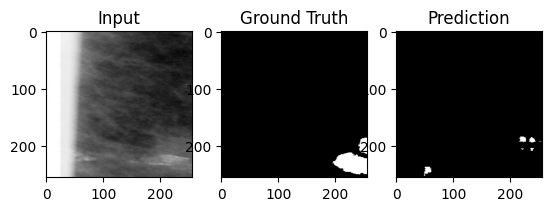

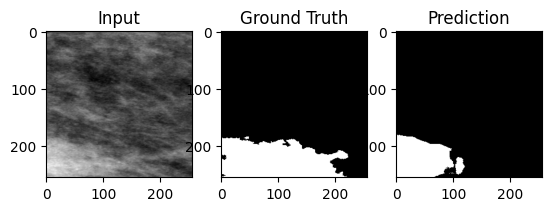

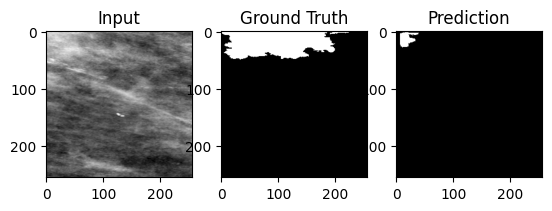

In [18]:
for images, masks in val_dataset.take(1):
    preds = model.predict(images)
    for i in range(3):  # visualize 3 examples
        plt.subplot(1, 3, 1)
        plt.imshow(images[i, ..., 0], cmap='gray')
        plt.title("Input")
        plt.subplot(1, 3, 2)
        plt.imshow(masks[i, ..., 0], cmap='gray')
        plt.title("Ground Truth")
        plt.subplot(1, 3, 3)
        plt.imshow(preds[i, ..., 0] > 0.5, cmap='gray')
        plt.title("Prediction")
        plt.show()

In [19]:
model.save_weights("/kaggle/working/ddsmtrainvaltfrecord-tpu-unetf.weights.h5")

In [29]:
model.load_weights("/kaggle/working/ddsmtrainvaltfrecord-tpu-unetf.weights.h5")
print("Weights loaded successfully!")

Weights loaded successfully!


In [21]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Load the model inside the TPU strategy scope
with strategy.scope():
    
    # Load previous weights
    model.load_weights("/kaggle/working/ddsmtrainvaltfrecord-tpu-unetf.weights.h5")
    print("Previous weights loaded successfully.")

    # Callbacks
    checkpointer = ModelCheckpoint(
        '/kaggle/working/unet-tpu.h5', save_best_only=True, verbose=1
    )
    early_stop = EarlyStopping(patience=15, restore_best_weights=True)

    # Fit the model again
    history_new = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=100,
        steps_per_epoch=40,
        callbacks=[checkpointer, early_stop]
    )

    # Save new weights
    model.save_weights("/kaggle/working/ddsmtrainvaltfrecord-tpu-unetf-continued.weights.h5")
    print("Continued weights saved.")

Previous weights loaded successfully.
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.5994 - loss: 0.6790
Epoch 1: val_loss improved from inf to 0.63906, saving model to /kaggle/working/unet-tpu.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 542ms/step - dice_coef: 0.5994 - loss: 0.6790 - val_dice_coef: 0.5797 - val_loss: 0.6391
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.5683 - loss: 0.6897
Epoch 2: val_loss did not improve from 0.63906
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 482ms/step - dice_coef: 0.5683 - loss: 0.6897 - val_dice_coef: 0.5549 - val_loss: 0.6645
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.5707 - loss: 0.6929
Epoch 3: val_loss did not improve from 0.63906
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 490ms/step - dice_coef: 0.5707 - loss: 0.6929 - val_dice_coef: 0.5356 - val_loss: 0.6825
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.5312 - loss: 0.7496
Epoch 4: val_loss did not improve from 0.63906
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 481ms/step - dice_coef: 0.5312 - loss: 0.7496 - val_dice_coef: 0.5568 - val_loss: 0.6811
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.5864 - loss: 0.6896
Epoch 5: val_loss did not i

40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 531ms/step - dice_coef: 0.5240 - loss: 0.7078 - val_dice_coef: 0.5789 - val_loss: 0.6310
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.5715 - loss: 0.6655
Epoch 7: val_loss did not improve from 0.63104
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 480ms/step - dice_coef: 0.5715 - loss: 0.6655 - val_dice_coef: 0.5661 - val_loss: 0.6490
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.4892 - loss: 0.8249
Epoch 8: val_loss did not improve from 0.63104
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 491ms/step - dice_coef: 0.4892 - loss: 0.8249 - val_dice_coef: 0.5545 - val_loss: 0.6658
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.5921 - loss: 0.6465
Epoch 9: val_loss did not improve from 0.63104
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 480ms/step - dice_coef: 0.5921 - loss: 0.6465 - val_dice_coef: 0.5560 - val_loss: 0.6492
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.5710 - loss: 0.6403
Epoch 10: val_loss improve

40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 527ms/step - dice_coef: 0.5710 - loss: 0.6403 - val_dice_coef: 0.5837 - val_loss: 0.6209
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.5803 - loss: 0.6398
Epoch 11: val_loss did not improve from 0.62089
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 489ms/step - dice_coef: 0.5803 - loss: 0.6398 - val_dice_coef: 0.5480 - val_loss: 0.6731
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.6110 - loss: 0.6137
Epoch 12: val_loss did not improve from 0.62089
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 480ms/step - dice_coef: 0.6110 - loss: 0.6137 - val_dice_coef: 0.5753 - val_loss: 0.6327
Epoch 13/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - dice_coef: 0.5836 - loss: 0.6618
Epoch 13: val_loss did not improve from 0.62089
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 488ms/step - dice_coef: 0.5836 - loss: 0.6618 - val_dice_coef: 0.5839 - val_loss: 0.6609
Epoch 14/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.6267 - loss: 0.5945
Epoch 14: val_loss i

40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 519ms/step - dice_coef: 0.6267 - loss: 0.5945 - val_dice_coef: 0.5859 - val_loss: 0.6144
Epoch 15/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.6033 - loss: 0.6430
Epoch 15: val_loss did not improve from 0.61443
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 490ms/step - dice_coef: 0.6033 - loss: 0.6430 - val_dice_coef: 0.5529 - val_loss: 0.6851
Epoch 16/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - dice_coef: 0.5821 - loss: 0.6482
Epoch 16: val_loss did not improve from 0.61443
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 503ms/step - dice_coef: 0.5821 - loss: 0.6482 - val_dice_coef: 0.5972 - val_loss: 0.6282
Epoch 17/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - dice_coef: 0.6070 - loss: 0.6655
Epoch 17: val_loss did not improve from 0.61443
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 482ms/step - dice_coef: 0.6070 - loss: 0.6655 - val_dice_coef: 0.5754 - val_loss: 0.6468
Epoch 18/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - dice_coef: 0.5893 - loss: 0.6732
Epoch 18: val_loss d

In [23]:
# Combine old and new training histories
combined_history = {
    "loss": history.history["loss"] + history_new.history["loss"],
    "val_loss": history.history["val_loss"] + history_new.history["val_loss"],
    "dice_coef": history.history["dice_coef"] + history_new.history["dice_coef"],
    "val_dice_coef": history.history["val_dice_coef"] + history_new.history["val_dice_coef"],
}

# Print nicely
print("Combined Training History (Epoch-wise):\n")
for i in range(len(combined_history["loss"])):
    print(f"Epoch {i+1:>2}: "
          f"Loss = {combined_history['loss'][i]:.4f}, "
          f"Val Loss = {combined_history['val_loss'][i]:.4f}, "
          f"Dice = {combined_history['dice_coef'][i]:.4f}, "
          f"Val Dice = {combined_history['val_dice_coef'][i]:.4f}")

Combined Training History (Epoch-wise):

Epoch  1: Loss = 1.5568, Val Loss = 1.3090, Dice = 0.2503, Val Dice = 0.1258
Epoch  2: Loss = 1.3254, Val Loss = 1.1871, Dice = 0.1386, Val Dice = 0.1688
Epoch  3: Loss = 1.1707, Val Loss = 1.1654, Dice = 0.1801, Val Dice = 0.2180
Epoch  4: Loss = 1.1084, Val Loss = 1.1165, Dice = 0.2804, Val Dice = 0.2457
Epoch  5: Loss = 1.0656, Val Loss = 1.0015, Dice = 0.3028, Val Dice = 0.3366
Epoch  6: Loss = 0.9339, Val Loss = 0.8844, Dice = 0.3963, Val Dice = 0.3924
Epoch  7: Loss = 1.0155, Val Loss = 0.8727, Dice = 0.3355, Val Dice = 0.4228
Epoch  8: Loss = 0.9257, Val Loss = 0.8791, Dice = 0.4286, Val Dice = 0.4200
Epoch  9: Loss = 0.9117, Val Loss = 0.8688, Dice = 0.4151, Val Dice = 0.4265
Epoch 10: Loss = 0.8916, Val Loss = 0.8203, Dice = 0.4545, Val Dice = 0.4381
Epoch 11: Loss = 0.8922, Val Loss = 0.8975, Dice = 0.4321, Val Dice = 0.4277
Epoch 12: Loss = 0.9350, Val Loss = 0.8104, Dice = 0.4198, Val Dice = 0.4333
Epoch 13: Loss = 0.8893, Val Loss =

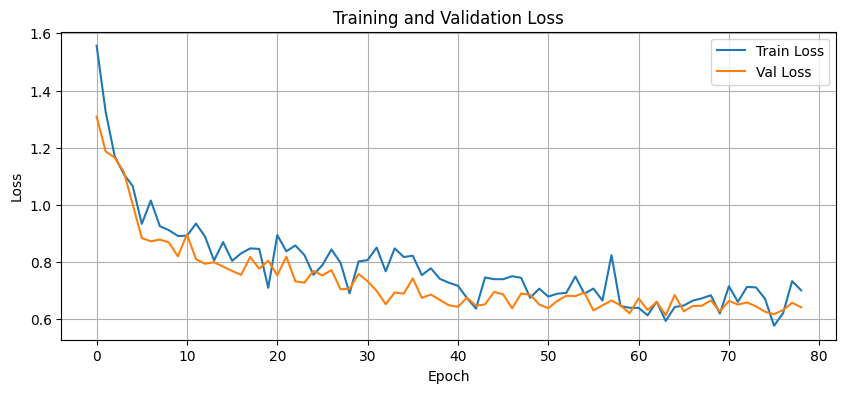

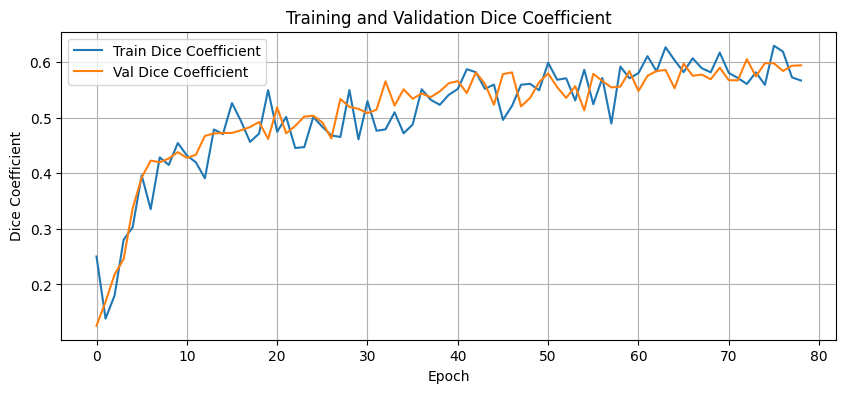

In [25]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(10, 4))
plt.plot(combined_history["loss"], label="Train Loss")
plt.plot(combined_history["val_loss"], label="Val Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot Dice Coefficient
plt.figure(figsize=(10, 4))
plt.plot(combined_history["dice_coef"], label="Train Dice Coefficient")
plt.plot(combined_history["val_dice_coef"], label="Val Dice Coefficient")
plt.title("Training and Validation Dice Coefficient")
plt.xlabel("Epoch")
plt.ylabel("Dice Coefficient")
plt.legend()
plt.grid(True)
plt.show()


Validation Dice Coefficient at Epoch 13: 0.5351
Validation Loss at Epoch 13: 0.7153


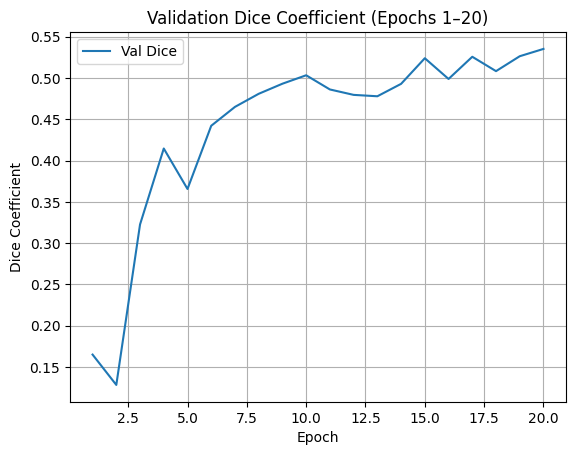

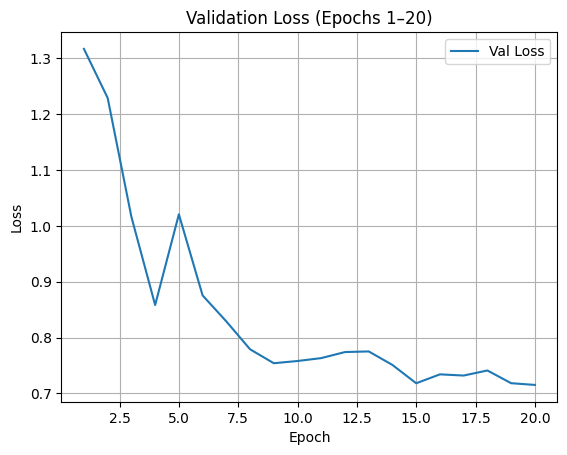

In [23]:
import matplotlib.pyplot as plt

# Take only up to epoch 14 (index 0 to 13)
val_dice_history = history.history['val_dice_coef'][:20]
val_loss_history = history.history['val_loss'][:20]

# Print last epoch's results (epoch 14 = index 13)
print(f"Validation Dice Coefficient at Epoch 13: {val_dice_history[-1]:.4f}")
print(f"Validation Loss at Epoch 13: {val_loss_history[-1]:.4f}")

# Plot Dice
plt.plot(range(1, 21), val_dice_history, label='Val Dice')
plt.title('Validation Dice Coefficient (Epochs 1–20)')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.plot(range(1, 21), val_loss_history, label='Val Loss')
plt.title('Validation Loss (Epochs 1–20)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step


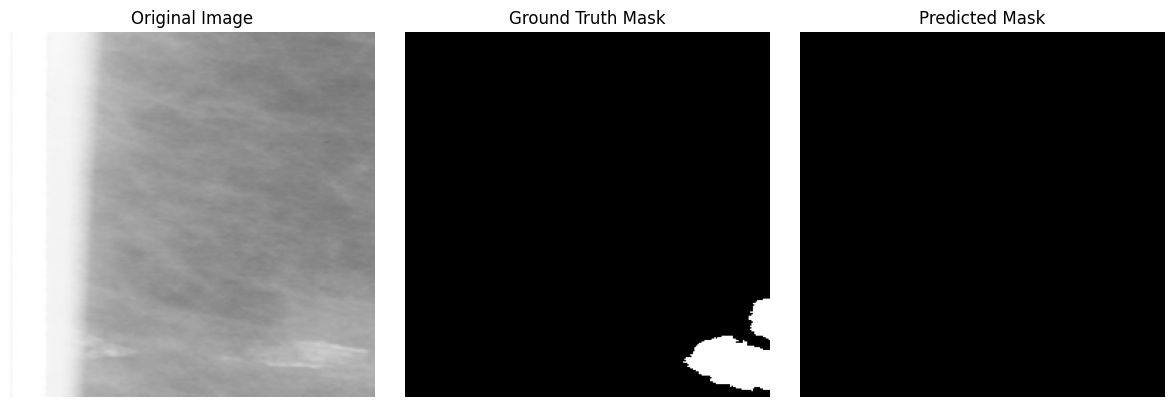

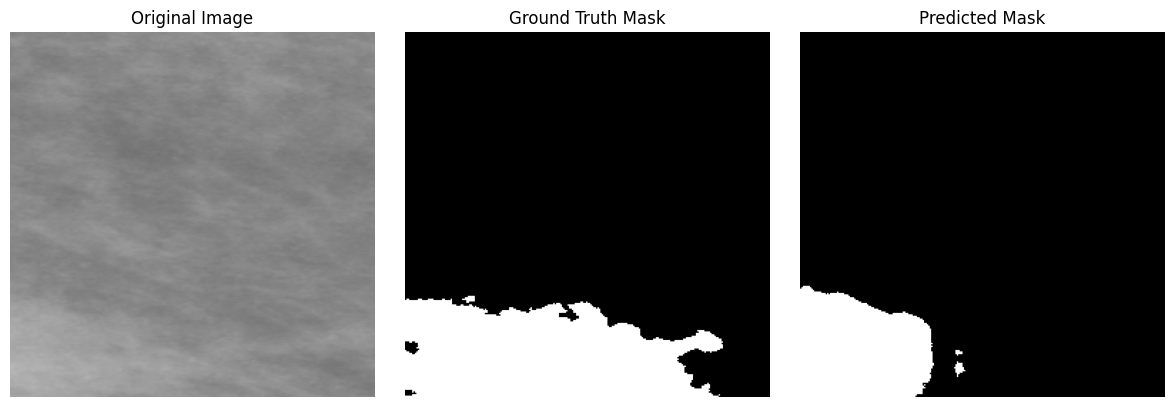

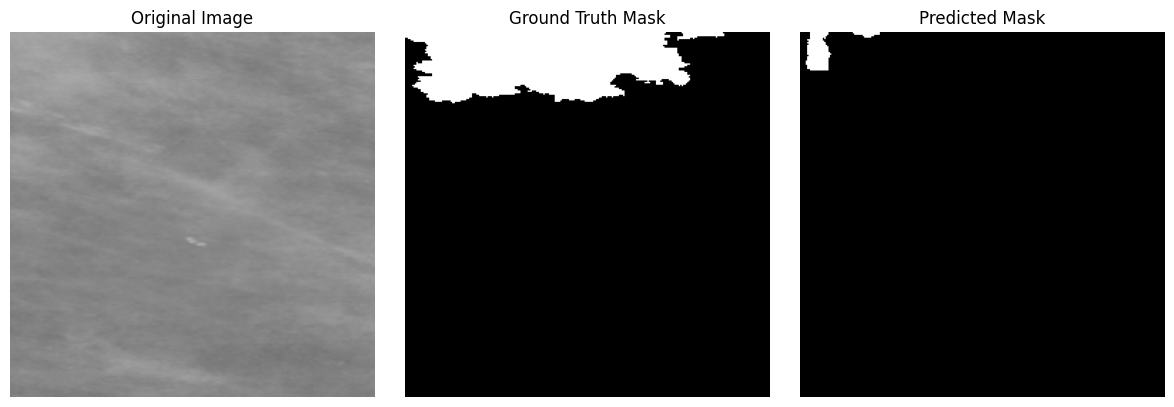

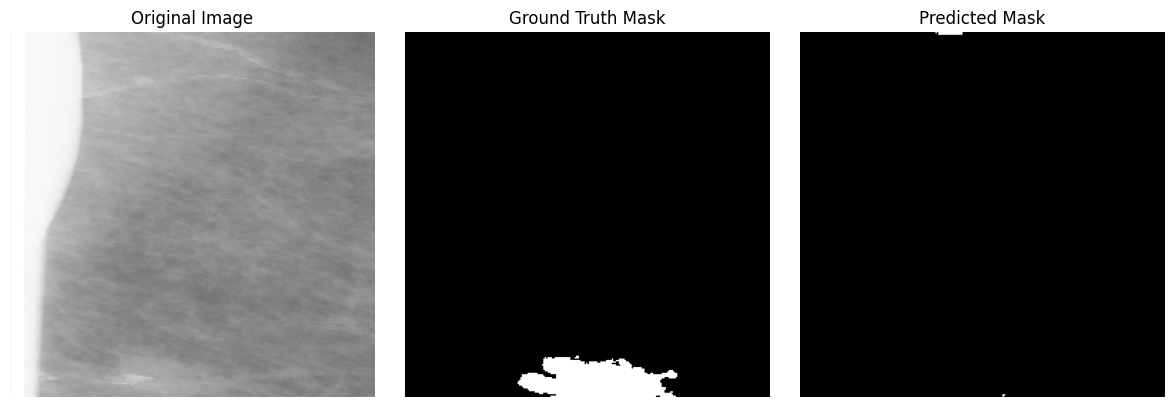

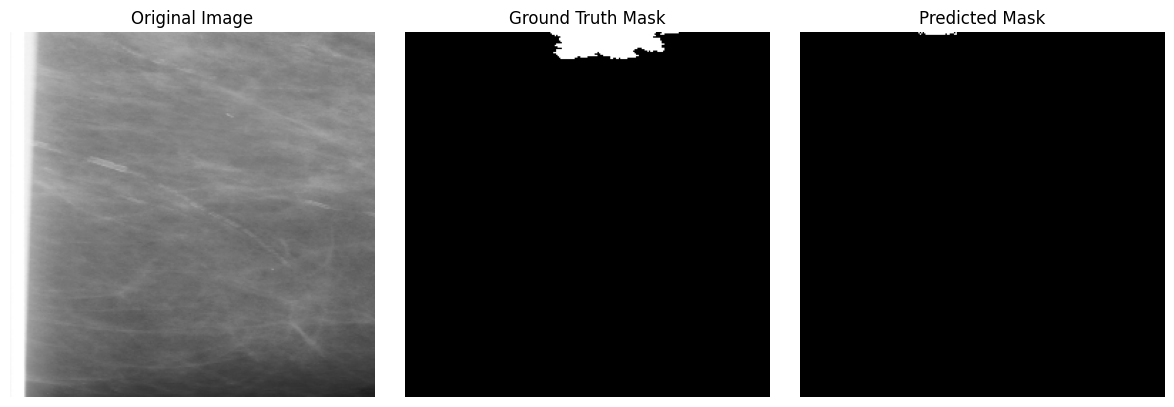

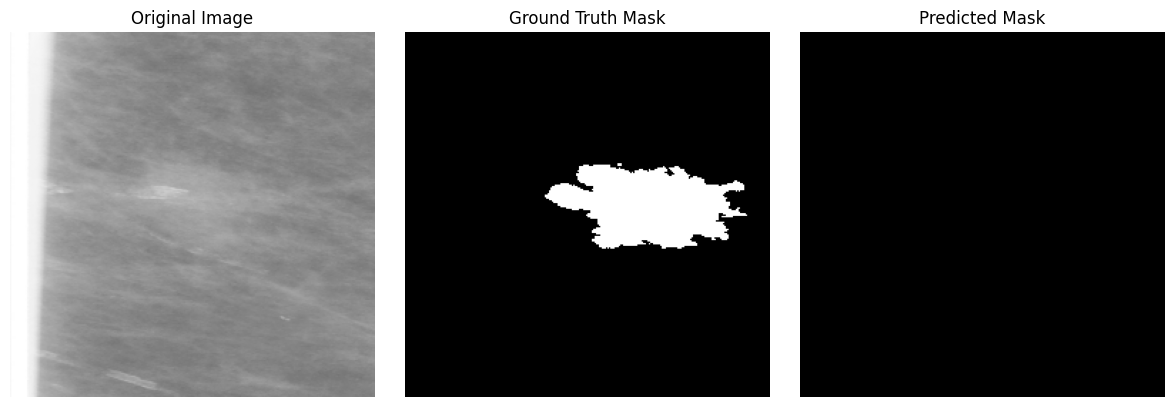

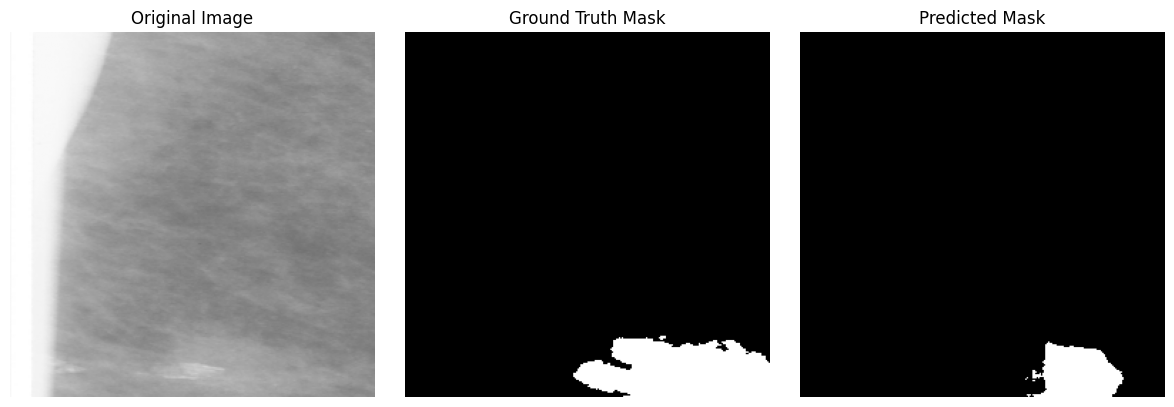

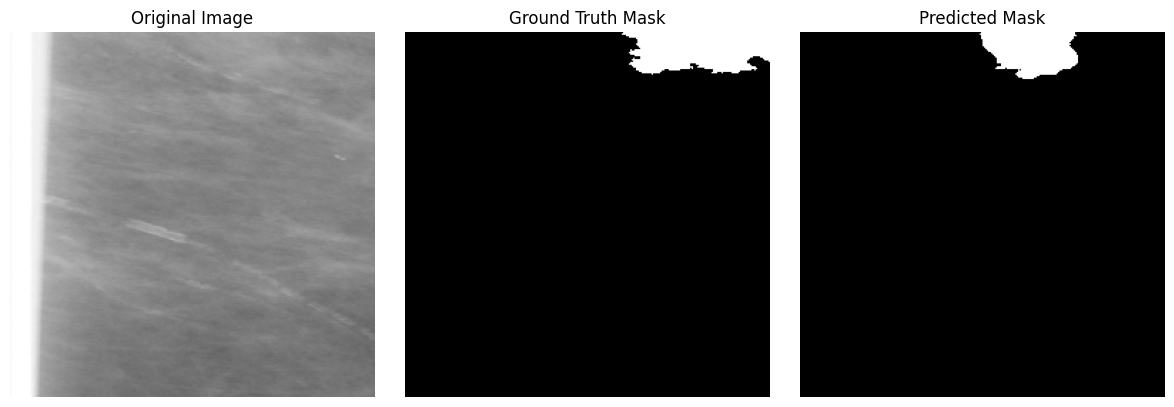

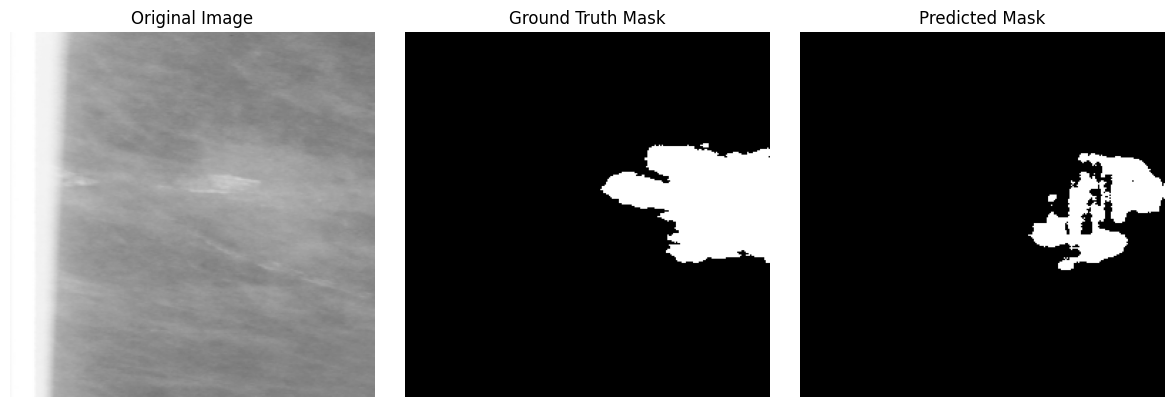

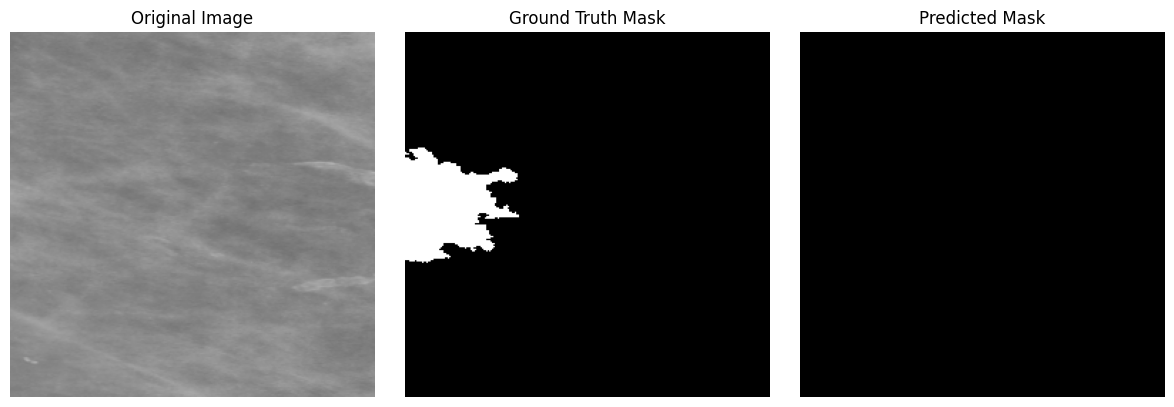

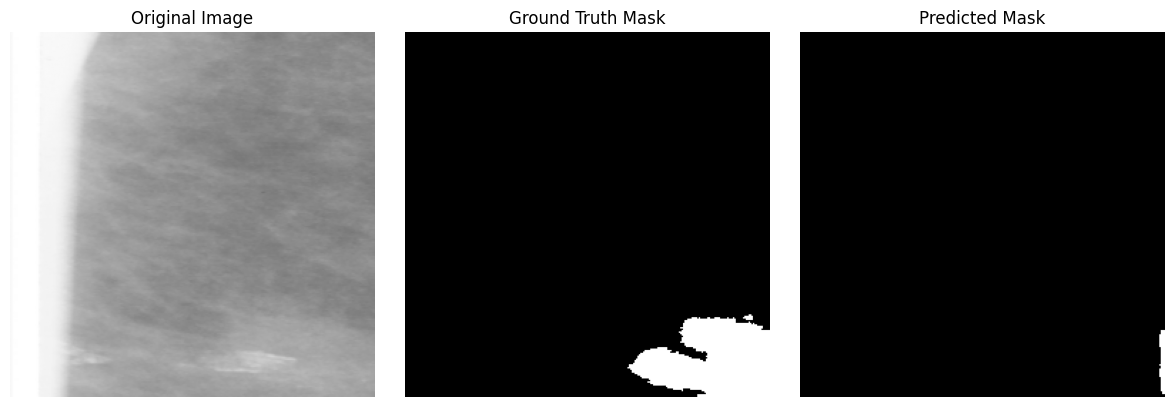

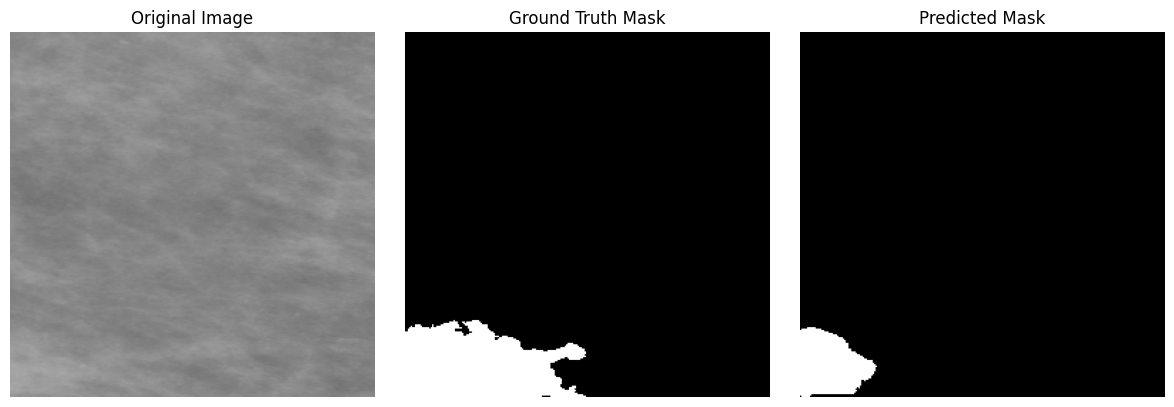

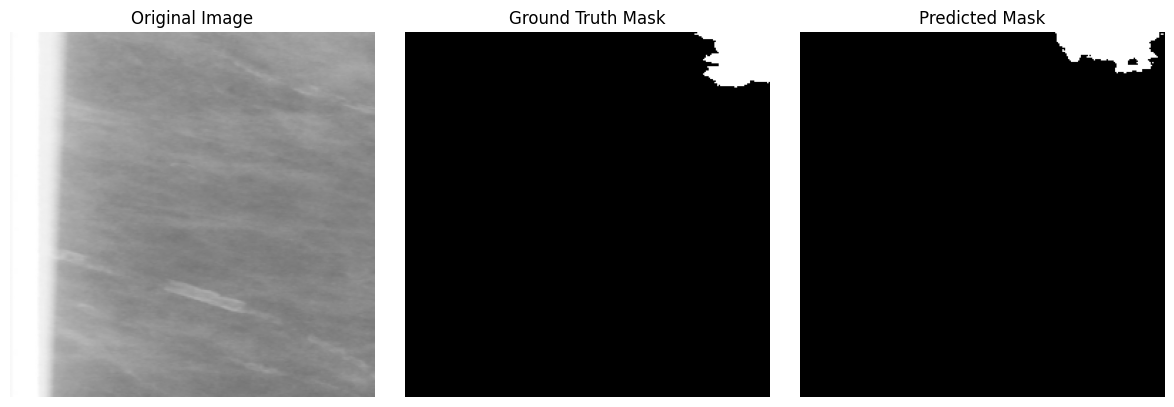

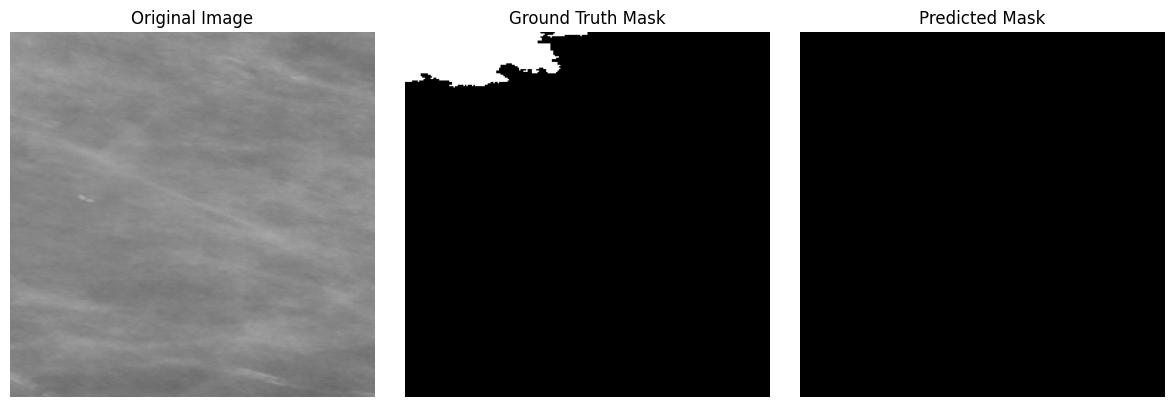

In [26]:
import matplotlib.pyplot as plt

# Take one batch from the test dataset
for images, masks in val_dataset.take(1):  # one batch
    preds = model.predict(images)

    # Display first 4 examples
    for i in range(14):
        image = images[i].numpy().squeeze()
        mask = masks[i].numpy().squeeze()
        pred = preds[i].squeeze()

        plt.figure(figsize=(12, 4))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(image, cmap='gray', vmin=0, vmax=1)
        plt.title("Original Image")
        plt.axis("off")

        # Ground Truth Mask
        plt.subplot(1, 3, 2)
        plt.imshow(mask, cmap='gray', vmin=0, vmax=1)
        plt.title("Ground Truth Mask")
        plt.axis("off")

        # Predicted Mask
        plt.subplot(1, 3, 3)
        plt.imshow(pred > 0.5, cmap='gray')  # Threshold at 0.5
        plt.title("Predicted Mask")
        plt.axis("off")

        plt.tight_layout()
        plt.show()